In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [63]:
df_index = pd.read_csv('economic_index.csv')

In [64]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [65]:
df_index.drop(columns=["Unnamed: 0","year","month"],axis=1,inplace=True)

In [66]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [67]:
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

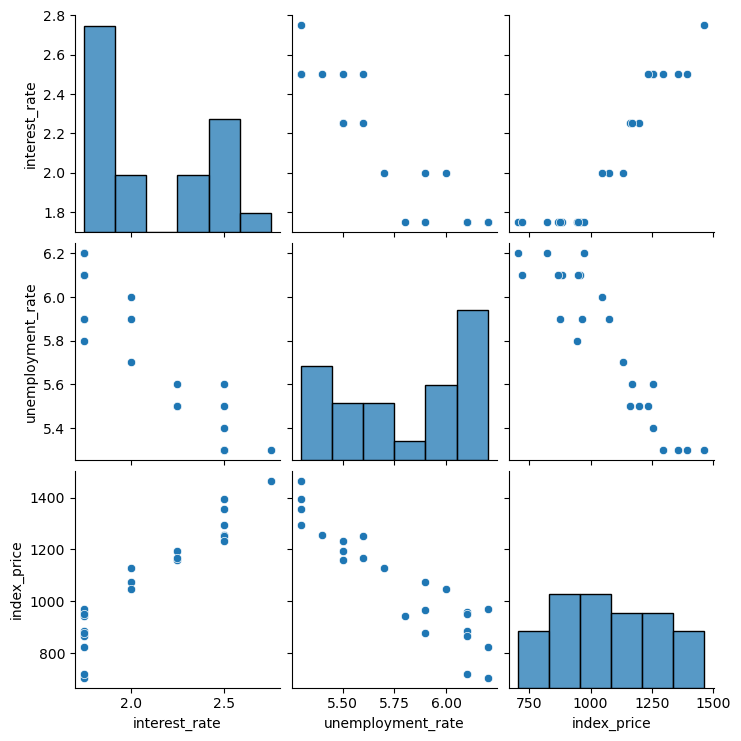

In [68]:
sns.pairplot(df_index)

In [69]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


In [70]:
# Visualizing Data Points

Text(0, 0.5, 'Unemployment Rate')

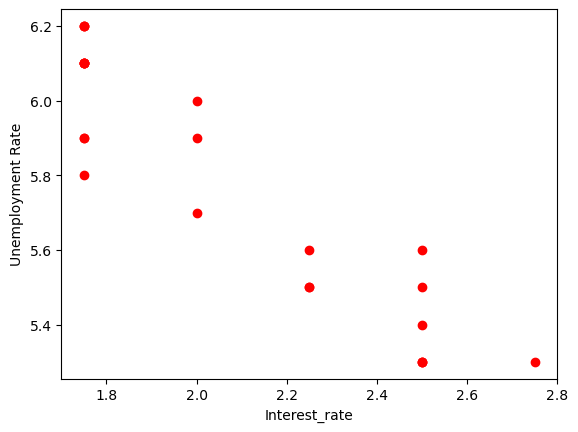

In [71]:
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color='r')
plt.xlabel('Interest_rate')
plt.ylabel('Unemployment Rate')

In [72]:
X = df_index.iloc[:,:-1]
y = df_index.iloc[:,-1]

In [73]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [74]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [75]:
from sklearn.model_selection import  train_test_split

In [76]:
X_train ,X_test , y_train , y_test = train_test_split(X,y,test_size=0.25, random_state=42)

In [77]:
from sklearn.preprocessing import StandardScaler

In [78]:
scaler = StandardScaler()

In [79]:
X_train=scaler.fit_transform(X_train)

In [80]:
X_test=scaler.transform(X_test)

In [81]:
from sklearn.linear_model import LinearRegression

In [82]:
regression = LinearRegression(n_jobs=-1)

In [83]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [84]:
from sklearn.model_selection import cross_val_score

In [85]:
validation_score = cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [86]:
np.mean(validation_score)

np.float64(-5914.828180162396)

In [87]:
y_pred = regression.predict(X_test)

In [88]:
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [89]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [90]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

5793.76288771258
59.93578152323556
76.11677139574813


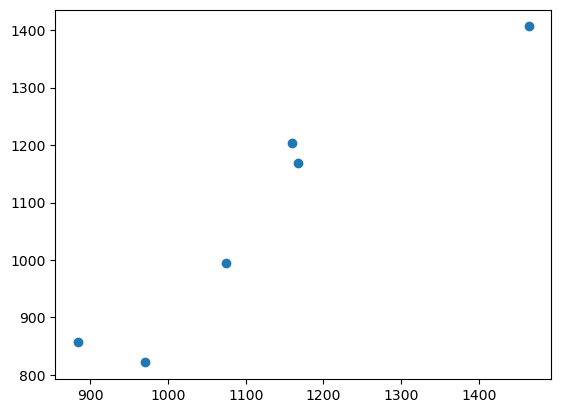

In [91]:
plt.scatter(y_test,y_pred)

In [92]:
residuals=y_test-y_pred

In [93]:
print(residuals)

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


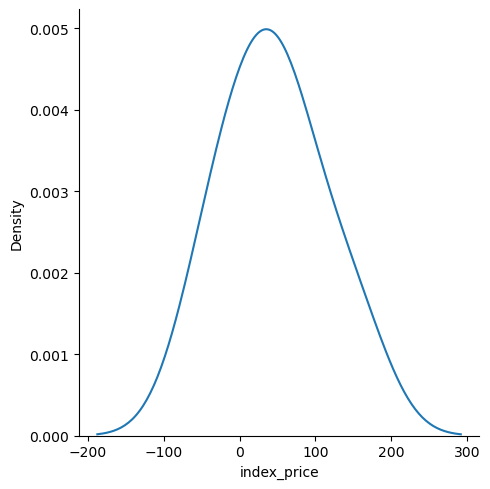

In [95]:
sns.displot(residuals,kind='kde')

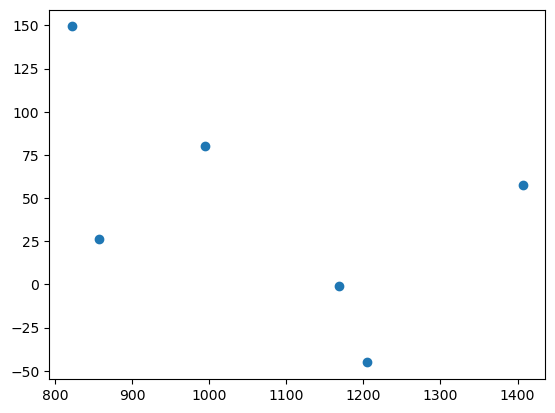

In [96]:
plt.scatter(y_pred,residuals)

In [97]:
regression.coef_

array([  88.27275507, -116.25716066])

In [98]:
regression.intercept_

np.float64(1053.4444444444443)

In [99]:
regression.predict(scaler.transform([[3,5.2]]))

c:\Users\jaisw\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1507.65565353])